Caricare tutti i file JSON della cartella locale su HDFS

In [1]:
!hdfs dfs -put -f  /Users/margheritasantarossa/Desktop/CVE/datasets/nvd/*.json /hdfs_dir/

2025-10-04 15:09:15,633 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Verificare che i file siano effettivamente caricati su HDFS

In [15]:
!hdfs dfs -ls /hdfs_dir/

2025-10-04 14:47:07,043 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Found 11 items
-rw-r--r--   1 margheritasantarossa supergroup   52514299 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2015.json
-rw-r--r--   1 margheritasantarossa supergroup   66078415 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2016.json
-rw-r--r--   1 margheritasantarossa supergroup   93883549 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2017.json
-rw-r--r--   1 margheritasantarossa supergroup   98708455 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2018.json
-rw-r--r--   1 margheritasantarossa supergroup  111356146 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2019.json
-rw-r--r--   1 margheritasantarossa supergroup  146390647 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2020.json
-rw-r--r--   1 margheritasantarossa supergroup  174250873 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2021.json
-rw-r--r--   1 margheritasantarossa supergroup  173719863 2025-10-04 12:47 /hdfs_dir/nvdc

In [15]:
# Se sei in notebook con cella magica
!pip install matplotlib pandas

  Using cached numpy-2.3.3-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 8.8 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 6.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 8.6 MB/s  0:00:00 eta 0:00:01
Using cached numpy-2.3.3-cp313-cp313-macosx_14_0_arm64.whl (5.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 11.5 MB/s  0:00:00 eta 0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [matplotlib]1 [matplotlib]


In [37]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 15.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 15.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode

# Crea/ricrea la sessione Spark con più memoria driver se serve
spark = SparkSession.builder \
        .appName("CVE_Analysis_Safe") \
        .config("spark.driver.memory", "4g") \
        .getOrCreate()

# Percorso del file JSON su HDFS
hdfs_file = "hdfs://localhost:9000/hdfs_dir/*.json"

# Leggi il file in modalità multiLine
df_raw = spark.read.option("multiLine", "true").json(hdfs_file)

df_raw.printSchema()
print(df_raw.count())
df_raw.select("version").distinct().show()

# Mostra solo il primo record
#df_selected.limit(1).show(truncate=False)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/06 16:11:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/06 16:12:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


root
 |-- format: string (nullable = true)
 |-- resultsPerPage: long (nullable = true)
 |-- startIndex: long (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- totalResults: long (nullable = true)
 |-- version: string (nullable = true)
 |-- vulnerabilities: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- cve: struct (nullable = true)
 |    |    |    |-- cisaActionDue: string (nullable = true)
 |    |    |    |-- cisaExploitAdd: string (nullable = true)
 |    |    |    |-- cisaRequiredAction: string (nullable = true)
 |    |    |    |-- cisaVulnerabilityName: string (nullable = true)
 |    |    |    |-- configurations: array (nullable = true)
 |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |-- nodes: array (nullable = true)
 |    |    |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |    |    |-- cpeMatch: array (nullable = true)
 |    |    |    |    |    |

11


+-------+
|version|
+-------+
|    2.0|
+-------+



In [4]:
from pyspark.sql import functions as F

# Esplodi l’array delle vulnerabilità
df_exploded = df_raw.select(F.explode("vulnerabilities").alias("vuln"))

# Estrai i campi principali
df_cve = df_exploded.select(
    F.col("vuln.cve.id").alias("cve_id"),
    F.expr("filter(vuln.cve.descriptions, x -> x.lang = 'en')[0].value").alias("description"),
    F.col("vuln.cve.published").alias("published"),
    F.col("vuln.cve.metrics.cvssMetricV31")[0].alias("cvss")  # versione più recente e standard
)

# Estrai punteggio e severità CVSS
df_cve = df_cve.select(
    "cve_id",
    "description",
    "published",
    F.col("cvss.cvssData.baseScore").alias("baseScore"),
    F.col("cvss.cvssData.baseSeverity").alias("severity")
)

# Aggiungi la colonna “anno” estratta dalla data di pubblicazione
df_cve = df_cve.withColumn("year", F.substring(F.col("published"), 1, 4))

# Rimuovi CVE senza severità
df_cve_filtered = df_cve.filter(F.col("severity").isNotNull())

# Controlla un campione
df_cve_filtered.show(5, truncate=False)
print("Totale CVE con severità:", df_cve_filtered.count())

+--------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------+---------+--------+----+
|cve_id        |description                                                                                                                                                                                                                                                                                                                                                                                                                                      

[Stage 8:==============================================>           (8 + 2) / 10]

Totale CVE con severità: 169724


In [5]:
df_grouped = df_cve_filtered.groupBy("year", "severity").count().orderBy("year")
df_grouped.show()

[Stage 11:===================================================>     (9 + 1) / 10]

+----+--------+-----+
|year|severity|count|
+----+--------+-----+
|2015|  MEDIUM|    9|
|2015|    HIGH|   41|
|2015|CRITICAL|   24|
|2016|     LOW|    7|
|2016|  MEDIUM|  201|
|2016|CRITICAL|   92|
|2016|    HIGH|  466|
|2017|CRITICAL|  271|
|2017|     LOW|   22|
|2017|  MEDIUM|  564|
|2017|    HIGH|  785|
|2018|  MEDIUM|  611|
|2018|    HIGH|  844|
|2018|CRITICAL|  319|
|2018|     LOW|   21|
|2019|     LOW|  191|
|2019|  MEDIUM| 3617|
|2019|    HIGH| 3620|
|2019|CRITICAL| 1174|
|2020|CRITICAL| 2450|
+----+--------+-----+
only showing top 20 rows



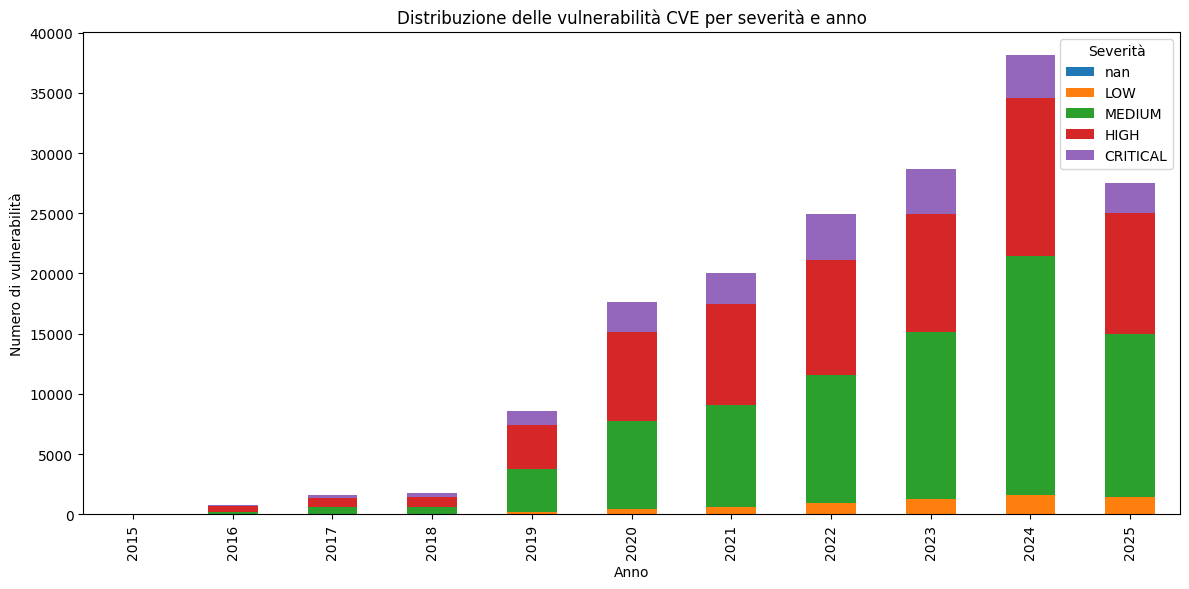

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Raggruppa per anno e severità
df_grouped = df_cve_filtered.groupBy("year", "severity").count().orderBy("year")

# Converti in pandas per il plotting
pdf = df_grouped.toPandas()

# Ordina le categorie di severità
severity_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
pdf["severity"] = pd.Categorical(pdf["severity"], categories=severity_order, ordered=True)

# Pivot per grafico
pdf_pivot = pdf.pivot(index="year", columns="severity", values="count").fillna(0)

# Plot stacked bar chart
pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribuzione delle vulnerabilità CVE per severità e anno")
plt.xlabel("Anno")
plt.ylabel("Numero di vulnerabilità")
plt.legend(title="Severità")
plt.tight_layout()
plt.show()

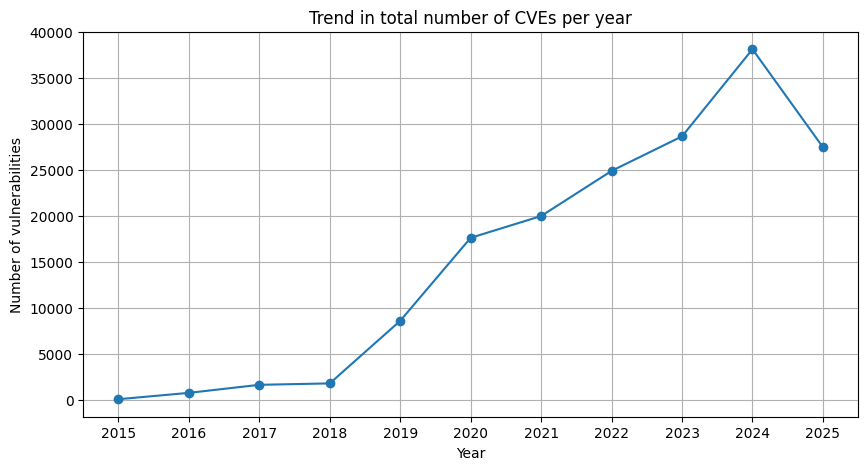

In [8]:
#Trend in total number of CVEs per year
#NOTE: 2025 is lower because still on-going

df_yearly = df_cve_filtered.groupBy("year").count().orderBy("year")
pdf_yearly = df_yearly.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_yearly["year"], pdf_yearly["count"], marker='o')
plt.title("Trend in total number of CVEs per year")
plt.xlabel("Year")
plt.ylabel("Number of vulnerabilities")
plt.grid(True)
plt.show()

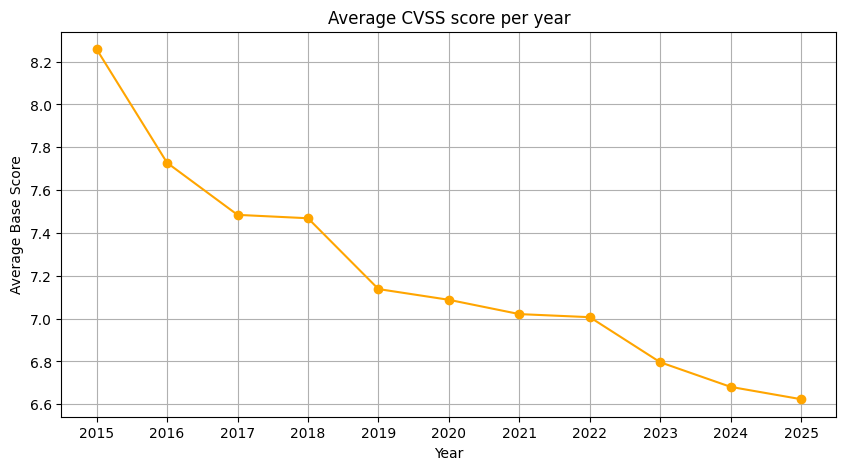

In [10]:
#Average CVSS score per year
df_score_trend = df_cve_filtered.groupBy("year").agg(
    F.avg("baseScore").alias("avg_score")
).orderBy("year")

pdf_score = df_score_trend.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_score["year"], pdf_score["avg_score"], marker='o', color='orange')
plt.title("Average CVSS score per year")
plt.xlabel("Year")
plt.ylabel("Average Base Score")
plt.grid(True)
plt.show()

#NOTE --> DA CAPIRE
#Se la media diminuisce, significa che:
#le vulnerabilità scoperte sono mediamente meno critiche,
#o che i sistemi sono più resilienti e i problemi più lievi.


In recent years, there has been a steady increase in the total number of reported vulnerabilities, accompanied by a decrease in the average CVSS score. This suggests an improved ability to detect and document less severe vulnerabilities, rather than a deterioration in the overall security of systems.

<Figure size 800x600 with 0 Axes>

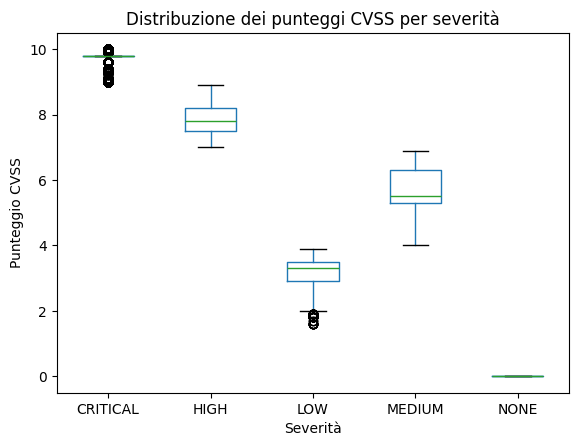

In [11]:
#Severity score distribution (boxplot)
pdf_scores = df_cve_filtered.select("severity", "baseScore").toPandas()

plt.figure(figsize=(8, 6))
pdf_scores.boxplot(column="baseScore", by="severity", grid=False)
plt.title("Distribuzione dei punteggi CVSS per severità")
plt.suptitle("")  # rimuove titolo doppio
plt.xlabel("Severità")
plt.ylabel("Punteggio CVSS")
plt.show()

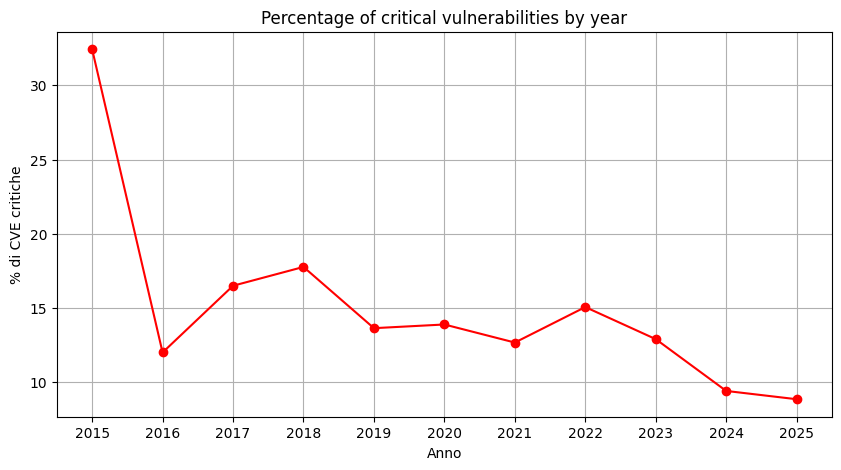

In [12]:
#Percentage of critical vulnerabilities by year

df_percent_critical = df_cve_filtered.groupBy("year").agg(
    (100 * F.sum(F.when(F.col("severity") == "CRITICAL", 1).otherwise(0)) / F.count("*")).alias("perc_critical")
).orderBy("year")

pdf_percent = df_percent_critical.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_percent["year"], pdf_percent["perc_critical"], marker='o', color='red')
plt.title("Percentage of critical vulnerabilities by year")
plt.xlabel("Anno")
plt.ylabel("% di CVE critiche")
plt.grid(True)
plt.show()

In [13]:
#Textual analysis of descriptions
from pyspark.sql.functions import lower, regexp_replace, split, explode

df_words = df_cve_filtered.select(
    explode(split(
        regexp_replace(lower(F.col("description")), "[^a-zA-Z0-9 ]", ""),
        " "
    )).alias("word")
)

df_top_words = df_words.groupBy("word").count().orderBy(F.desc("count"))
df_top_words.filter(df_top_words.word.isin("sql", "xss", "overflow", "injection")).show()

[Stage 63:===================================================>     (9 + 1) / 10]

+---------+-----+
|     word|count|
+---------+-----+
|injection|17737|
|      xss|15981|
|      sql|15336|
| overflow|11927|
+---------+-----+



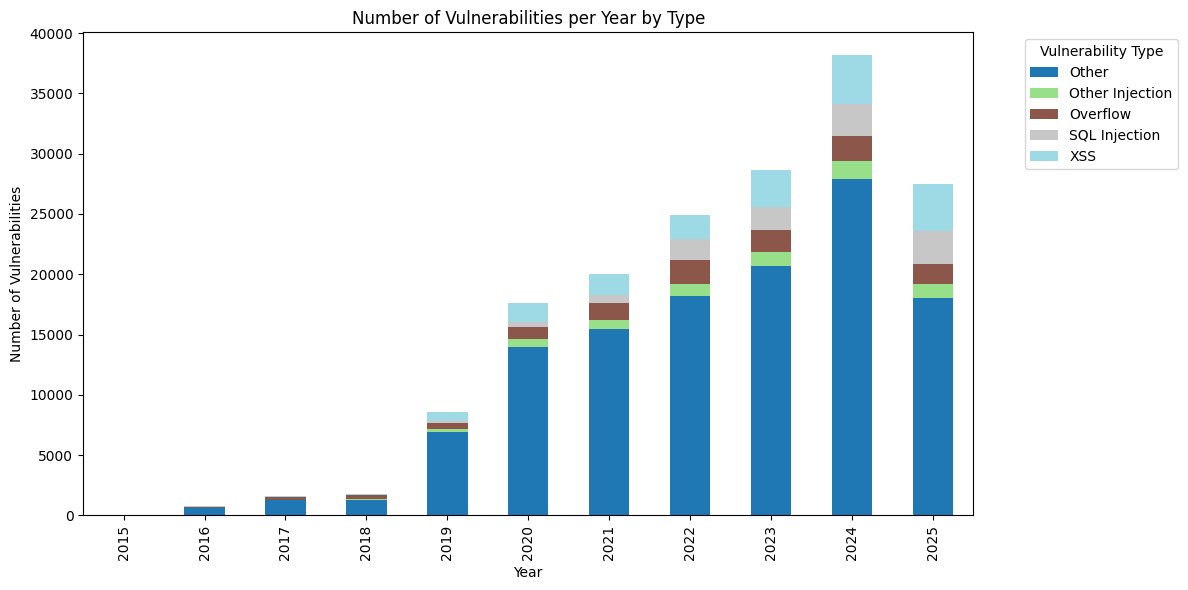

In [14]:
from pyspark.sql import functions as F

# Define a new column 'vuln_type' based on keywords in the description
df_vuln_type = df_cve_filtered.withColumn(
    "vuln_type",
    F.when(F.lower(F.col("description")).contains("sql injection"), "SQL Injection")
     .when(F.lower(F.col("description")).contains("xss"), "XSS")
     .when(F.lower(F.col("description")).contains("overflow"), "Overflow")
     .when(F.lower(F.col("description")).contains("injection"), "Other Injection")
     .otherwise("Other")
)

df_vuln_year = df_vuln_type.groupBy("year", "vuln_type").count().orderBy("year")
pdf_vuln_year = df_vuln_year.toPandas()

# Pivot table for stacked bar chart
pdf_pivot = pdf_vuln_year.pivot(index="year", columns="vuln_type", values="count").fillna(0)

import matplotlib.pyplot as plt

pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20"
)

plt.title("Number of Vulnerabilities per Year by Type")
plt.xlabel("Year")
plt.ylabel("Number of Vulnerabilities")
plt.legend(title="Vulnerability Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
from pyspark.sql.functions import lower, regexp_replace, split, explode

# Clean and split descriptions into words
df_words = df_cve_filtered.select(
    explode(
        split(
            regexp_replace(lower(F.col("description")), "[^a-zA-Z0-9 ]", ""), 
            " "
        )
    ).alias("word")
)

df_word_counts = df_words.groupBy("word").count().orderBy(F.desc("count"))
df_word_counts.show(50)  # Top 50 words

[Stage 74:===================================================>     (9 + 1) / 10]

+-------------+------+
|         word| count|
+-------------+------+
|          the|364263|
|           to|301915|
|           in|217476|
|            a|204601|
|             |182917|
|           of|158542|
|          and|139078|
|vulnerability|128424|
|         this|105552|
|           an|103980|
|           is|103445|
|          for| 59464|
|     attacker| 55376|
|     versions| 50703|
|        issue| 48344|
|       allows| 47102|
|         with| 46426|
|           be| 43667|
|         user| 43412|
|          can| 42048|
|           by| 41972|
|        could| 41438|
|       before| 41429|
|           on| 41271|
|         that| 40725|
|          via| 39454|
|          was| 38438|
|         code| 35861|
|       access| 35618|
|          has| 35262|
|         file| 34474|
|           as| 33543|
|    arbitrary| 32076|
|         from| 31947|
|          may| 31390|
|           or| 31275|
|          not| 30024|
|           it| 29736|
|     affected| 29565|
|       remote| 28517|
|          

In [16]:
vuln_keywords = ["sql", "xss", "overflow", "injection", "csrf", "dos", "rce", "authentication", "privilege", "bypass"]
df_top_vuln_words = df_word_counts.filter(df_word_counts.word.isin(vuln_keywords))
df_top_vuln_words.show()

[Stage 77:=============================================>           (8 + 2) / 10]

+--------------+-----+
|          word|count|
+--------------+-----+
|     injection|17737|
|           xss|15981|
|           sql|15336|
|     privilege|11954|
|      overflow|11927|
|authentication| 7767|
|        bypass| 6865|
|           dos| 5765|
|          csrf| 5583|
|           rce|  962|
+--------------+-----+



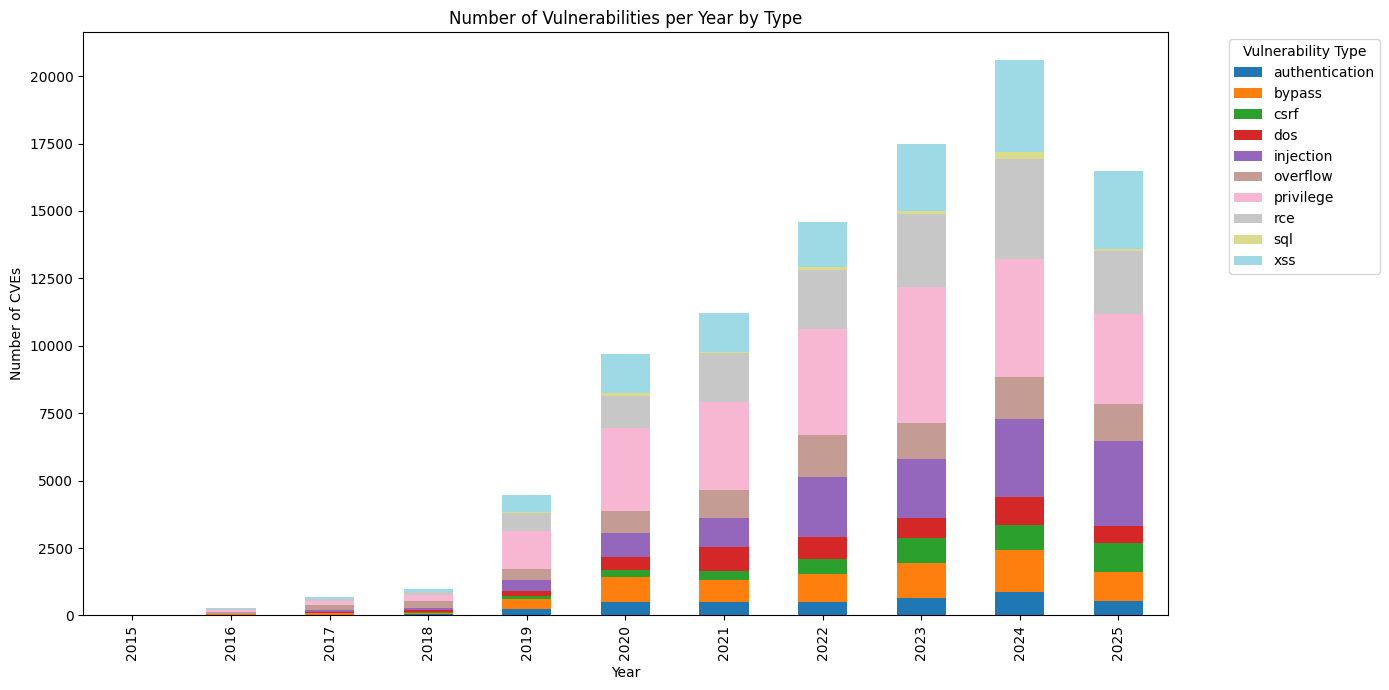

In [20]:
from pyspark.sql.functions import lower, col, when, lit

# Start with a column 'vuln_type' filled with None
df_cve_types = df_cve_filtered.withColumn("vuln_type", lit(None))

# List of vulnerability keywords
vuln_keywords = ["sql", "xss", "overflow", "injection", "csrf", "dos", "rce", "authentication", "privilege", "bypass"]

# Assign the type based on keywords in the description
for keyword in vuln_keywords:
    df_cve_types = df_cve_types.withColumn(
        "vuln_type",
        when(lower(col("description")).contains(keyword), keyword).otherwise(col("vuln_type"))
    )

# Keep only rows where vuln_type was assigned
df_cve_types = df_cve_types.filter(col("vuln_type").isNotNull())

df_grouped = df_cve_types.groupBy("year", "vuln_type").count().orderBy("year")
pdf_grouped = df_grouped.toPandas()

pdf_pivot = pdf_grouped.pivot(index="year", columns="vuln_type", values="count").fillna(0)

pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    colormap="tab20"
)

plt.title("Number of Vulnerabilities per Year by Type")
plt.xlabel("Year")
plt.ylabel("Number of CVEs")
plt.legend(title="Vulnerability Type", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

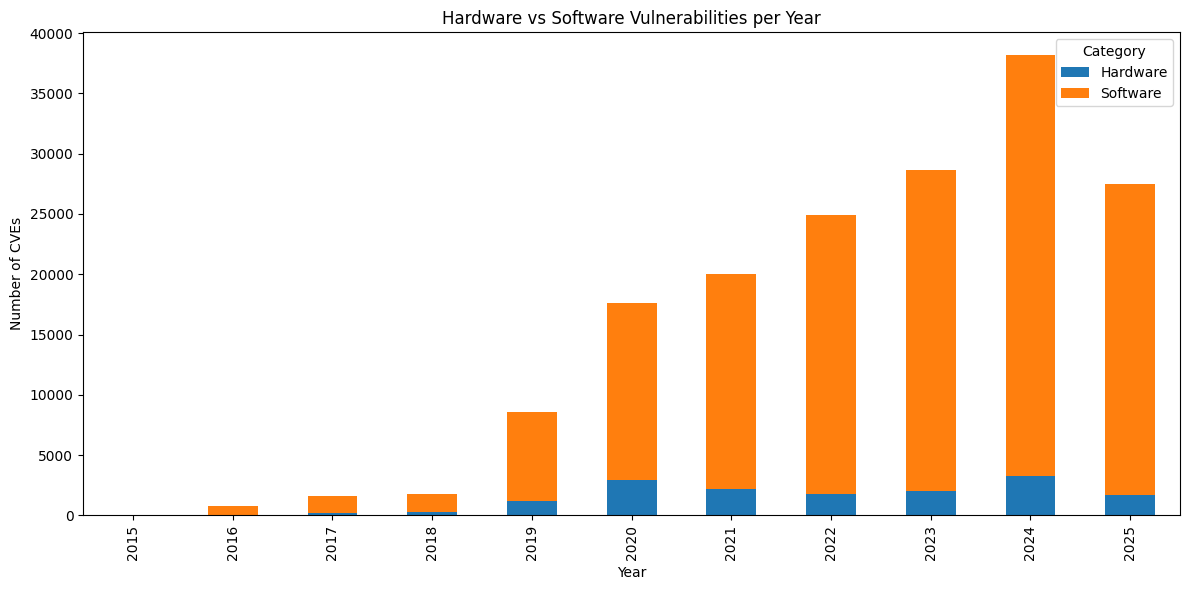

In [21]:
#Hardware vulnerabilities might contain words like "hardware", "chip", "firmware", "processor", "device", "embedded".
#Software vulnerabilities are everything else (most CVEs), often mentioning "code", "application", "system", "library", "plugin".

from pyspark.sql.functions import when, lower, col, lit

# Define hardware keywords
hardware_keywords = ["hardware", "chip", "firmware", "processor", "device", "embedded"]

# Start with 'vuln_category' as 'Software' by default
df_cve_category = df_cve_filtered.withColumn("vuln_category", lit("Software"))

# Check if description contains any hardware keyword
for hw in hardware_keywords:
    df_cve_category = df_cve_category.withColumn(
        "vuln_category",
        when(lower(col("description")).contains(hw), "Hardware").otherwise(col("vuln_category"))
    )


df_category_grouped = df_cve_category.groupBy("year", "vuln_category").count().orderBy("year")
pdf_category_grouped = df_category_grouped.toPandas()

pdf_category_pivot = pdf_category_grouped.pivot(index="year", columns="vuln_category", values="count").fillna(0)

pdf_category_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#1f77b4", "#ff7f0e"]
)

plt.title("Hardware vs Software Vulnerabilities per Year")
plt.xlabel("Year")
plt.ylabel("Number of CVEs")
plt.legend(title="Category")
plt.tight_layout()
plt.show()